In [54]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from icecream import ic

import numpy as np
import utils.debug
from IPython.display import Audio
from scipy.io import wavfile

from utils.harmonic import get_harmonic_oscillation
from utils.plotting import show_plot
from utils.sampling import get_linspace

[https://www.gitaristam.ru/school/frequency.htm](https://www.gitaristam.ru/school/frequency.htm)

| Нота | Буква | Суб-контр (0) | Контр (1) | Большая (2) | Малая (3) | 1-я (4) | 2-я (5) | 3-я (6) | 4-я (7) | 5-я (8) |
|---|---|---|---|---|---|---|---|---|---|---|
| До | C | - | 32.70 | 65.41 | 130.82 | 261.63 | 523.25 | 1046.50 | 2093.00 | 4186.00 |
| До-диез | C# | - | 34.65 | 69.30 | 138.59 | 277.18 | 554.36 | 1108.70 | 2217.40 | 4434.80 |
| Ре | D | - | 36.95 | 73.91 | 147.83 | 293.66 | 587.32 | 1174.60 | 2349.20 | 4698.40 |
| Ре-диез | D# | - | 38.88 | 77.78 | 155.56 | 311.13 | 622.26 | 1244.50 | 2489.00 | 4978.00 |
| Ми | E | 20.61 | 41.21 | 82.41 | 164.81 | 329.63 | 659.26 | 1318.50 | 2637.00 | 5274.00 |
| Фа | F | 21.82 | 43.65 | 87.31 | 174.62 | 349.23 | 698.46 | 1396.90 | 2793.80 | - |
| Фа-диез | F# | 23.12 | 46.25 | 92.50 | 185.00 | 369.99 | 739.98 | 1480.00 | 2960.00 | - |
| Соль | G | 24.50 | 49.00 | 98.00 | 196.00 | 392.00 | 784.00 | 1568.00 | 3136.00 | - |
| Соль-диез | G# | 25.95 | 51.90 | 103.80 | 207.00 | 415.30 | 830.60 | 1661.20 | 3332.40 | - |
| Ля | A | 27.50 | 55.00 | 110.00 | 220.00 | 440.00 | 880.00 | 1720.00 | 3440.00 | - |
| Си-бемоль | A# | 29.13 | 58.26 | 116.54 | 233.08 | 466.16 | 932.32 | 1864.60 | 3729.20 | - |
| Си | B | 30.87 | 61.74 | 123.48 | 246.96 | 493.88 | 987.75 | 1975.50 | 3951.00 | - |

In [55]:
# частоты нот в герцах: буква ноты и номер октавы
NOTES = {
    "E0": 20.61, "F0": 21.82, "F#0": 23.12, "G0": 24.50, "G#0": 25.95, "A0": 27.50,
    "A#0": 29.13, "B0": 30.87,
    "C1": 32.70, "C#1": 34.65, "D1": 36.95, "D#1": 38.88, "E1": 41.21, "F1": 43.65,
    "F#1": 46.25, "G1": 49.00, "G#1": 51.90, "A1": 55.00, "A#1": 58.26, "B1": 61.74,
    "C2": 65.41, "C#2": 69.30, "D2": 73.91, "D#2": 77.78, "E2": 82.41, "F2": 87.31,
    "F#2": 92.50, "G2": 98.00, "G#2": 103.80, "A2": 110.00, "A#2": 116.54, "B2": 123.48,
    "C3": 130.82, "C#3": 138.59, "D3": 147.83, "D#3": 155.56, "E3": 164.81, "F3": 174.62,
    "F#3": 185.00, "G3": 196.00, "G#3": 207.00, "A3": 220.00, "A#3": 233.08, "B3": 246.96,
    "C4": 261.63, "C#4": 277.18, "D4": 293.66, "D#4": 311.13, "E4": 329.63, "F4": 349.23,
    "F#4": 369.99, "G4": 392.00, "G#4": 415.30, "A4": 440.00, "A#4": 466.16, "B4": 493.88,
    "C5": 523.25, "C#5": 554.36, "D5": 587.32, "D#5": 622.26, "E5": 659.26, "F5": 698.46,
    "F#5": 739.98, "G5": 784.00, "G#5": 830.60, "A5": 880.00, "A#5": 932.32, "B5": 987.75,
    "C6": 1046.50, "C#6": 1108.70, "D6": 1174.60, "D#6": 1244.50, "E6": 1318.50, "F6": 1396.90,
    "F#6": 1480.00, "G6": 1568.00, "G#6": 1661.20, "A6": 1720.00, "A#6": 1864.60, "B6": 1975.50,
    "C7": 2093.00, "C#7": 2217.40, "D7": 2349.20, "D#7": 2489.00, "E7": 2637.00, "F7": 2793.80,
    "F#7": 2960.00, "G7": 3136.00, "G#7": 3332.40, "A7": 3440.00, "A#7": 3729.20, "B7": 3951.00,
    "C8": 4186.00, "C#8": 4434.80, "D8": 4698.40, "D#8": 4978.00, "E8": 5274.00,
}


ic(NOTES["A4"])
ic(NOTES["C4"])
ic(NOTES["A5"]);

ic| NOTES["A4"]: 440.0
ic| NOTES["C4"]: 261.63
ic| NOTES["A5"]: 880.0


In [56]:
FS = 44100  # частота дискретизации
FADE_START = 0.01  # время fade начала
FADE_END = 0.01  # время fade конца


def note_wave(note: str, duration: float) -> np.ndarray:
    count = int(FS * duration)  # отсчёты
    t = get_linspace(start=0, stop=duration, fs=count)

    if note == "P":
        return np.zeros(count)

    wave = get_harmonic_oscillation(1, NOTES[note], 0, wave=np.sin)(t)

    fade_start_count = int(FS * FADE_START)
    fade_end_count = int(FS * FADE_END)
    fade_start = np.linspace(0, 1, fade_start_count)
    fade_end = np.linspace(1, 0, fade_end_count)
    wave[:fade_start_count] *= fade_start
    wave[-fade_end_count:] *= fade_end

    return wave

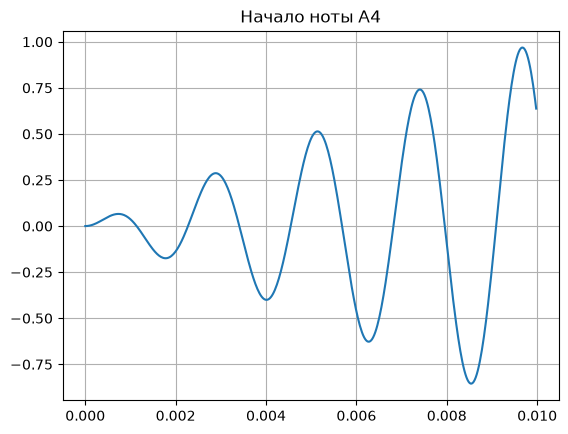

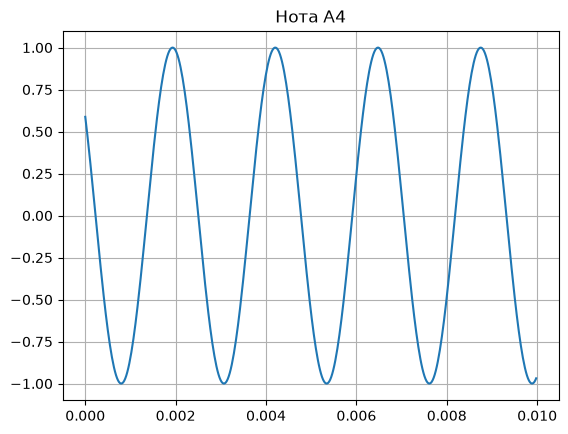

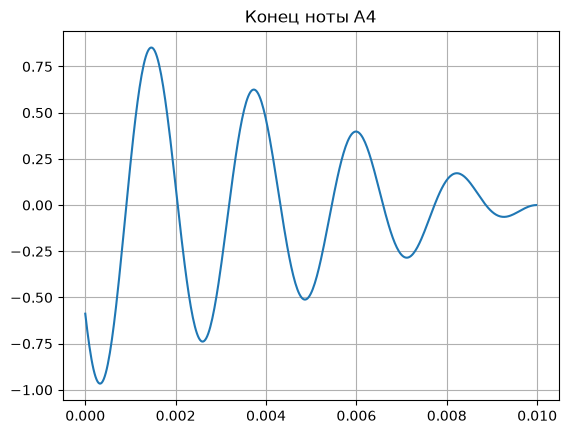

In [57]:
show_plot(
    t=get_linspace(start=0, stop=FADE_START, fs=int(FS * FADE_START)),
    func_val=note_wave("A4", 0.5)[:int(FS * FADE_START)],
    title="Начало ноты A4",
)
show_plot(
    t=get_linspace(start=0, stop=FADE_END, fs=int(FS * FADE_END)),
    func_val=note_wave("A4", 0.5)[int(FS * FADE_START):int(FS * FADE_START) + int(FS * FADE_END)],
    title="Нота A4",
)
show_plot(
    t=get_linspace(start=0, stop=FADE_END, fs=int(FS * FADE_END)),
    func_val=note_wave("A4", 0.5)[-int(FS * FADE_END):],
    title="Конец ноты A4",
)

In [58]:
beat = 0.4  # длительность одной единицы в секундах

melody_matrix = [
    ["E4", 2], ["E4", 1], ["F4", 1], ["G4", 1],
    ["G4", 1], ["F4", 3], ["E4", 1], ["D4", 1],
    ["C4", 1.44], ["C4", 1], ["D4", 2], ["E4", 1]
]

In [59]:
def play_melody(matrix: list, beat: float) -> np.ndarray:
    waves = [note_wave(note, length * beat) for note, length in matrix]

    return np.concatenate(waves)


melody = play_melody(melody_matrix, beat)

ic(melody.size)
ic(melody.size / FS);

ic| melody.size: 290001
ic| melody.size / FS: 6.575986394557823


In [60]:
Audio(melody, rate=FS)

In [61]:
BITS = 16
AS_TYPE = np.int16

max_int = 2**(BITS - 1) - 1
melody_int16 = (melody * max_int).astype(AS_TYPE)

ic(max_int)

# wavfile.write("melody.wav", FS, melody_int16)

ic| max_int: 32767


32767